# Embeddings & Semantic Search Intuition (Deep Dive)
### Practice Notebook

**Assumed pre-installed libraries:** `numpy`, `scikit-learn`, `matplotlib`,
`sentence-transformers`

The first time you run this notebook, `sentence-transformers` will download
the `all-MiniLM-L6-v2` model weights (~90MB) from the Hugging Face Hub, so an
internet connection is needed once. After that it's cached locally.


## 1. Dense vs. sparse embeddings

| | Dense embeddings | Sparse embeddings |
|---|---|---|
| **What it is** | A fixed-length vector (e.g., 384 dims) where every dimension is a learned, dense feature | A very high-dimensional vector (vocabulary-sized) that is mostly zeros, with weights on the specific words present |
| **Captures** | Semantic *meaning* — "car" and "automobile" end up close together | Exact keyword/term overlap — "car" and "automobile" are treated as unrelated unless the exact word matches |
| **Examples** | `sentence-transformers` models, OpenAI/Cohere embedding APIs | TF-IDF, BM25 |
| **Good for** | Conceptual/semantic queries, paraphrases, cross-lingual search | Exact term matching, rare/technical terms, keyword search, explainability |

In practice, many production systems use **hybrid search** — combining a
sparse (keyword) score with a dense (semantic) score — to get the best of
both. Let's build both from scratch on the same small corpus so you can see
the difference directly.


In [11]:
corpus = [
    "The cat sat on the mat.",
    "A dog was running in the park.",
    "Machine learning models can generate text.",
    "The feline rested on the rug.",           # paraphrase of sentence 1
    "Stock prices fell sharply after the announcement.",
    "Large language models are a type of machine learning model.",
    "Aeroplanes are faster mode of transport"
]
query = "An automobile is a mode of transport."


### Sparse embeddings (TF-IDF)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus + [query])
corpus_tfidf = tfidf_matrix[:-1]
query_tfidf = tfidf_matrix[-1]

sparse_scores = sk_cosine(query_tfidf, corpus_tfidf)[0]
for text, score in sorted(zip(corpus, sparse_scores), key=lambda x: -x[1]):
    print(f"{score:.3f}  {text}")


0.404  Aeroplanes are faster mode of transport
0.087  Large language models are a type of machine learning model.
0.000  The cat sat on the mat.
0.000  A dog was running in the park.
0.000  Machine learning models can generate text.
0.000  The feline rested on the rug.
0.000  Stock prices fell sharply after the announcement.


Notice TF-IDF gives **near-zero similarity everywhere** — the query
"automobile... transport" shares almost no exact words with any sentence in
the corpus, even though sentence 2 ("dog running in the park") and sentence 1
("cat on the mat") are about everyday physical scenes, and none of them are
actually about vehicles. This is the core limitation of sparse retrieval:
zero lexical overlap = zero relevance score, regardless of meaning.


### Dense embeddings (sentence-transformers)

In [13]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

corpus_embeddings = model.encode(corpus)
query_embedding = model.encode([query])

print("Embedding shape per sentence:", corpus_embeddings.shape)


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 53fb2d43-60f4-4f14-9dcf-e5cd0e797bf1)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json
Retrying in 1s [Retry 1/5].


Embedding shape per sentence: (7, 384)


In [14]:
dense_scores = sk_cosine(query_embedding, corpus_embeddings)[0]
for text, score in sorted(zip(corpus, dense_scores), key=lambda x: -x[1]):
    print(f"{score:.3f}  {text}")


0.483  Aeroplanes are faster mode of transport
0.091  Large language models are a type of machine learning model.
0.074  Machine learning models can generate text.
0.063  A dog was running in the park.
0.056  The feline rested on the rug.
0.043  The cat sat on the mat.
-0.045  Stock prices fell sharply after the announcement.


**Exercise 3.1:** Which sentence does the dense model rank highest for the
"automobile" query? Does that make more sense than the TF-IDF ranking? Try
your own query (e.g., a paraphrase of sentence 3) and compare both rankings
again.


## 2. Similarity metrics: cosine, dot product, Euclidean distance

In [15]:
import numpy as np

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def dot_product(a, b):
    return np.dot(a, b)

def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

a = corpus_embeddings[0]   # "The cat sat on the mat."
b = corpus_embeddings[3]   # "The feline rested on the rug." (paraphrase)
c = corpus_embeddings[4]   # "Stock prices fell sharply..." (unrelated)

print("cat/mat  vs  feline/rug (similar meaning):")
print(f"  cosine similarity : {cosine_similarity(a, b):.4f}")
print(f"  dot product       : {dot_product(a, b):.4f}")
print(f"  euclidean distance: {euclidean_distance(a, b):.4f}")

print("\ncat/mat  vs  stock prices (unrelated):")
print(f"  cosine similarity : {cosine_similarity(a, c):.4f}")
print(f"  dot product       : {dot_product(a, c):.4f}")
print(f"  euclidean distance: {euclidean_distance(a, c):.4f}")


cat/mat  vs  feline/rug (similar meaning):
  cosine similarity : 0.5490
  dot product       : 0.5490
  euclidean distance: 0.9497

cat/mat  vs  stock prices (unrelated):
  cosine similarity : 0.0438
  dot product       : 0.0438
  euclidean distance: 1.3829


**Reading the numbers:** for the similar pair, cosine similarity should be
high (closer to 1) and Euclidean distance small; for the unrelated pair, the
opposite. Dot product behaves similarly to cosine *here* because
`sentence-transformers` embeddings are (roughly) normalized to unit length —
but that's not true of every embedding model, which is why the choice of
metric matters:

- **Cosine similarity** — measures the *angle* between vectors, ignoring
  magnitude. Most common choice for text embeddings since it's invariant to
  vector length.
- **Dot product** — measures both angle and magnitude. Equivalent to cosine
  similarity *only* when vectors are normalized to length 1. Faster to
  compute (no normalization step), which is why it's the default metric in
  many vector DB indexes when embeddings are pre-normalized.
- **Euclidean distance** — measures straight-line distance in vector space.
  Sensitive to magnitude; more common in classic clustering (e.g., k-means)
  than in text retrieval, but still supported by most vector DBs.

**Exercise 3.2:** Verify for yourself whether these embeddings are unit-normalized by computing `np.linalg.norm(a)`. What does that imply about whether cosine similarity and dot product will always agree here?


## 3. Visualizing embedding space

384 dimensions can't be plotted directly, so we project down to 2D using
PCA (a simple, deterministic option — t-SNE/UMAP give prettier separation on
larger datasets but are non-deterministic and overkill for a 6-sentence toy
example).


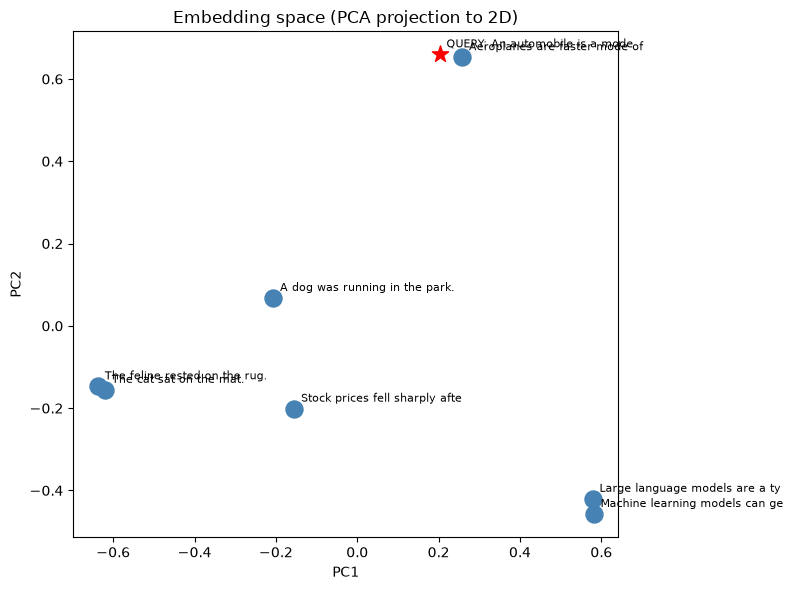

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

all_embeddings = np.vstack([corpus_embeddings, query_embedding])
labels = corpus + ["QUERY: " + query]

pca = PCA(n_components=2)
reduced = pca.fit_transform(all_embeddings)

plt.figure(figsize=(8, 6))
for i, label in enumerate(labels):
    marker = "*" if label.startswith("QUERY") else "o"
    color = "red" if label.startswith("QUERY") else "steelblue"
    plt.scatter(reduced[i, 0], reduced[i, 1], marker=marker, s=150, color=color)
    plt.annotate(label[:30], (reduced[i, 0], reduced[i, 1]), fontsize=8,
                 xytext=(5, 5), textcoords="offset points")

plt.title("Embedding space (PCA projection to 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


**Exercise 3.3:** Which two sentences cluster closest together in the plot?
Does that match your intuition about which sentences are semantically
related? Add 2–3 of your own sentences to `corpus` (mix related and
unrelated topics) and re-run the plot.


## 4. Hands-on: full semantic search workflow

Putting it together: embed a corpus once, embed a new query, rank by cosine
similarity, and return the top-k most relevant chunks — this is the
"retrieve" step from Day 1's RAG pipeline, now built with real embeddings
instead of keyword overlap.


In [18]:
def semantic_search(query: str, corpus: list, model, top_k: int = 3):
    corpus_emb = model.encode(corpus)
    query_emb = model.encode([query])
    scores = sk_cosine(query_emb, corpus_emb)[0]
    ranked = sorted(zip(corpus, scores), key=lambda x: -x[1])
    return ranked[:top_k]

test_queries = [
    "What did the cat do?",
    "Tell me about AI and text generation.",
    "What happened to the market?",
]

for q in test_queries:
    print(f"\nQuery: {q}")
    for text, score in semantic_search(q, corpus, model, top_k=4):
        print(f"  {score:.3f}  {text}")



Query: What did the cat do?
  0.542  The feline rested on the rug.
  0.496  The cat sat on the mat.
  0.147  A dog was running in the park.
  0.077  Machine learning models can generate text.

Query: Tell me about AI and text generation.
  0.683  Machine learning models can generate text.
  0.372  Large language models are a type of machine learning model.
  0.092  Aeroplanes are faster mode of transport
  0.007  Stock prices fell sharply after the announcement.

Query: What happened to the market?
  0.419  Stock prices fell sharply after the announcement.
  0.116  A dog was running in the park.
  0.078  The feline rested on the rug.
  0.039  The cat sat on the mat.


**Exercise 3.4 (mini deliverable):** Take the chunk records you built in
Day 2's `build_chunk_records` exercise (or the `sentence_chunks` from Day 2's
sample document) and run `semantic_search` over them with 2–3 questions you
invent. Report which chunk was retrieved for each question and whether it
was actually the correct one. This is the retrieval half of the pipeline you
will formally evaluate on Day 5.
